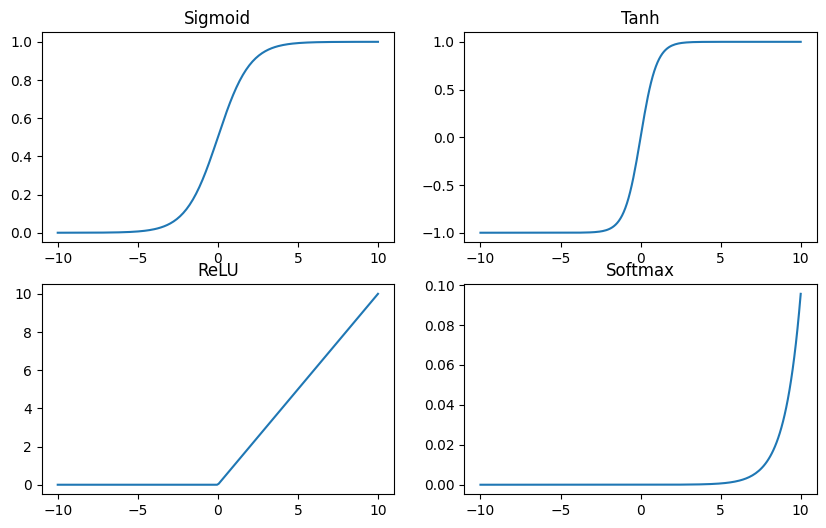

In [1]:
# Part A: Activation Functions Visualization

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

# Activation Functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
softmax = np.exp(x) / np.sum(np.exp(x))

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.plot(x, sigmoid); plt.title("Sigmoid")
plt.subplot(2,2,2)
plt.plot(x, tanh); plt.title("Tanh")
plt.subplot(2,2,3)
plt.plot(x, relu); plt.title("ReLU")
plt.subplot(2,2,4)
plt.plot(x, softmax); plt.title("Softmax")
plt.show()


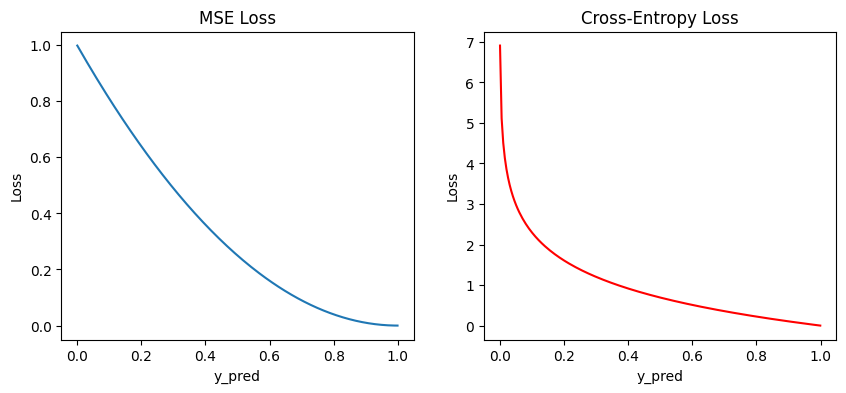

In [2]:
# Part B: Loss Functions Visualization

y_true = np.array([0, 1])   # target: class = 1
y_pred = np.linspace(0.001, 0.999, 200)

# MSE Loss
mse_loss = (y_true[1] - y_pred) ** 2

# Cross-Entropy Loss
cross_entropy_loss = -(y_true[1]*np.log(y_pred) + y_true[0]*np.log(1-y_pred))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_pred, mse_loss, label="MSE")
plt.title("MSE Loss"); plt.xlabel("y_pred"); plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(y_pred, cross_entropy_loss, label="Cross-Entropy", color="red")
plt.title("Cross-Entropy Loss"); plt.xlabel("y_pred"); plt.ylabel("Loss")
plt.show()

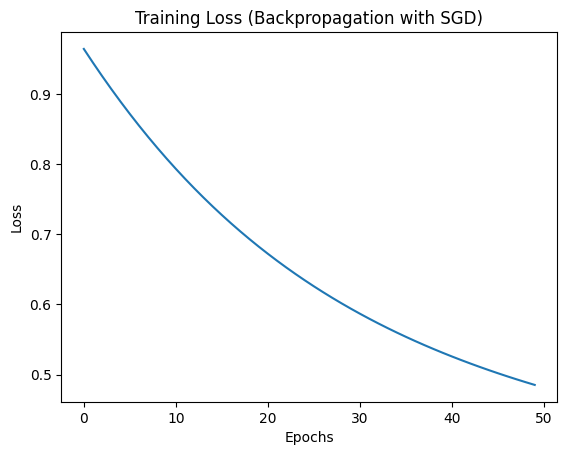

In [3]:
# Part C: Backpropagation Implementation with PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Neural Network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Train using backpropagation
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

losses = []
for epoch in range(50):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

# Plot training loss
plt.plot(losses)
plt.title("Training Loss (Backpropagation with SGD)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

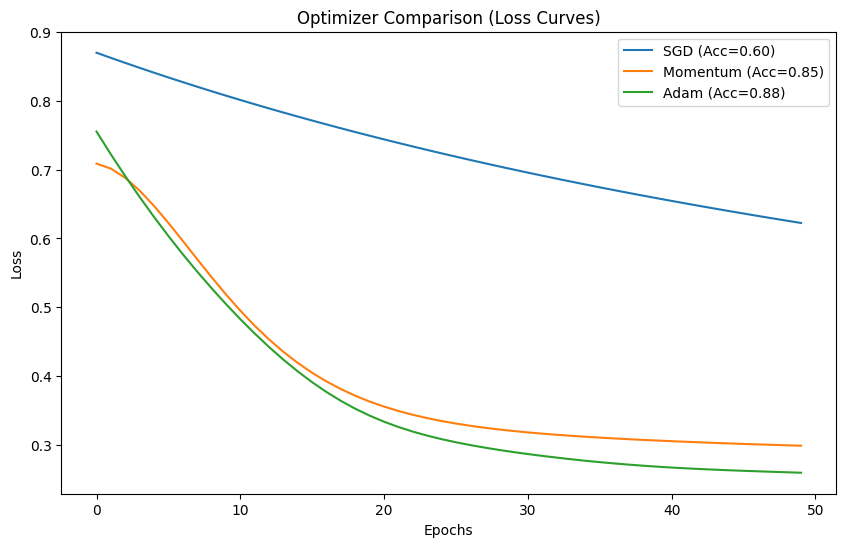

SGD Final Accuracy: 0.60
Momentum Final Accuracy: 0.85
Adam Final Accuracy: 0.88


In [4]:
# Part D: Optimizer Comparison

def train_model(optimizer_type, epochs=50):
    model = SimpleNN()
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_type == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_type == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.01)

    losses = []
    for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # Accuracy
    with torch.no_grad():
        preds = model(X_test).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()
    return losses, acc

# Train with all optimizers
optimizers = ["SGD", "Momentum", "Adam"]
results = {}

plt.figure(figsize=(10,6))
for opt in optimizers:
    losses, acc = train_model(opt, epochs=50)
    results[opt] = acc
    plt.plot(losses, label=f"{opt} (Acc={acc:.2f})")

plt.title("Optimizer Comparison (Loss Curves)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Print accuracies
for opt, acc in results.items():
    print(f"{opt} Final Accuracy: {acc:.2f}")